<a href="https://colab.research.google.com/github/AleximperV/ThucHanhDeepLearning/blob/main/Tuan_2/ANNBai1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
# Load dữ liệu CIFAR10 có sẵn trong TensorFlow
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Số lượng nhãn:", len(class_names))

Số lượng nhãn: 10


In [4]:
# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Chuyển y từ dạng [[1], [5], ...] thành [1, 5, ...]
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

print("Min pixel:", X_train.min())
print("Max pixel:", X_train.max())

print("Các class trong y_train:", np.unique(y_train))

Min pixel: 0.0
Max pixel: 1.0
Các class trong y_train: [0 1 2 3 4 5 6 7 8 9]


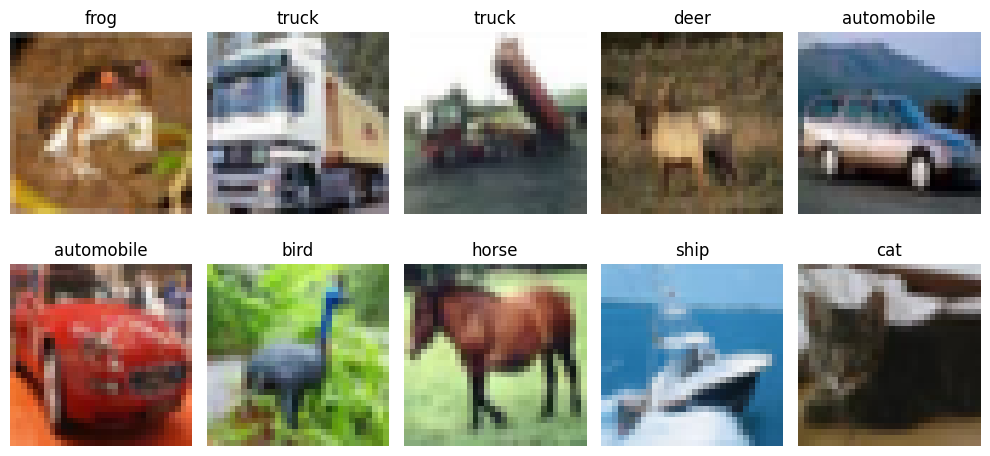

In [5]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),

    Dense(512, activation="relu"),
    Dropout(0.3),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.2482 - loss: 2.0350 - val_accuracy: 0.3263 - val_loss: 1.8844
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - accuracy: 0.2979 - loss: 1.9053 - val_accuracy: 0.3290 - val_loss: 1.8474
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.3163 - loss: 1.8586 - val_accuracy: 0.3475 - val_loss: 1.8108
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3272 - loss: 1.8330 - val_accuracy: 0.3779 - val_loss: 1.7635
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.3412 - loss: 1.8020 - val_accuracy: 0.3967 - val_loss: 1.7290
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3495 - loss: 1.7749 - val_accuracy: 0.3948 - val_loss: 1.7311
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3601 - loss: 1.7581 - val_accuracy: 0.4002 - val_loss: 1.7093
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3642 - loss: 1.7484 - 

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 1.6050925254821777
Test accuracy: 0.4424999952316284


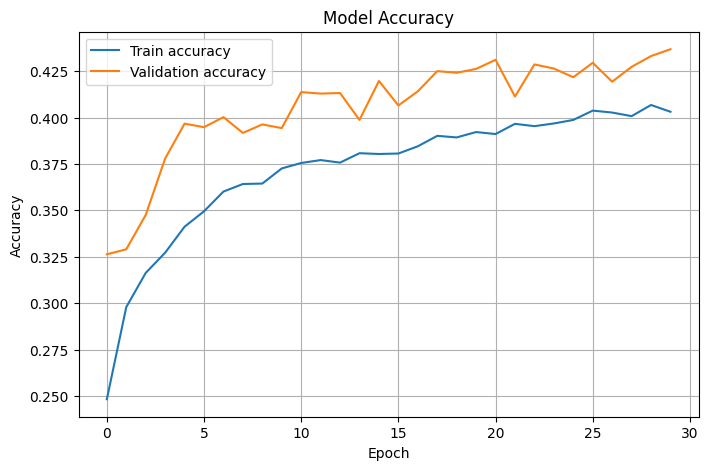

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

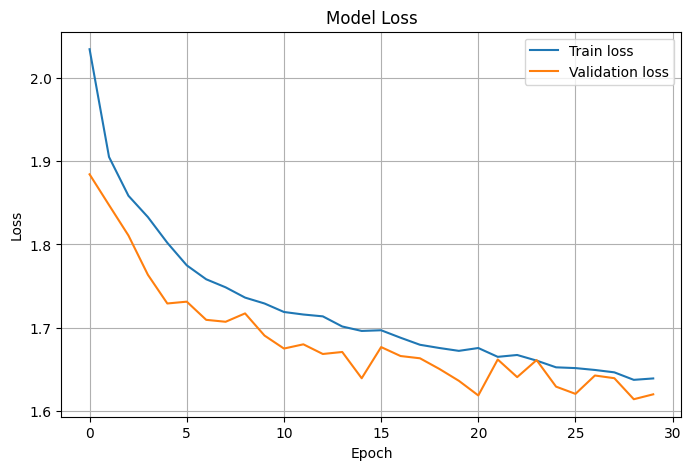

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Nhãn dự đoán: 3 - cat
Nhãn thực tế: 3 - cat


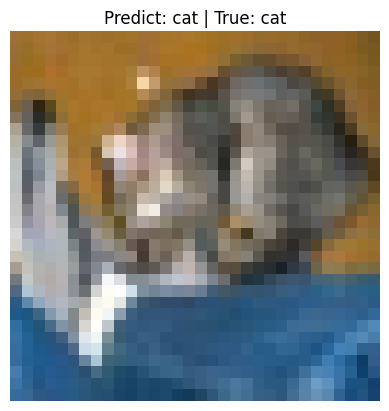

In [11]:
index = 0

prediction = model.predict(X_test[index:index+1])
predicted_label = np.argmax(prediction)
true_label = y_test[index]

print("Nhãn dự đoán:", predicted_label, "-", class_names[predicted_label])
print("Nhãn thực tế:", true_label, "-", class_names[true_label])

plt.imshow(X_test[index])
plt.title(f"Predict: {class_names[predicted_label]} | True: {class_names[true_label]}")
plt.axis("off")
plt.show()

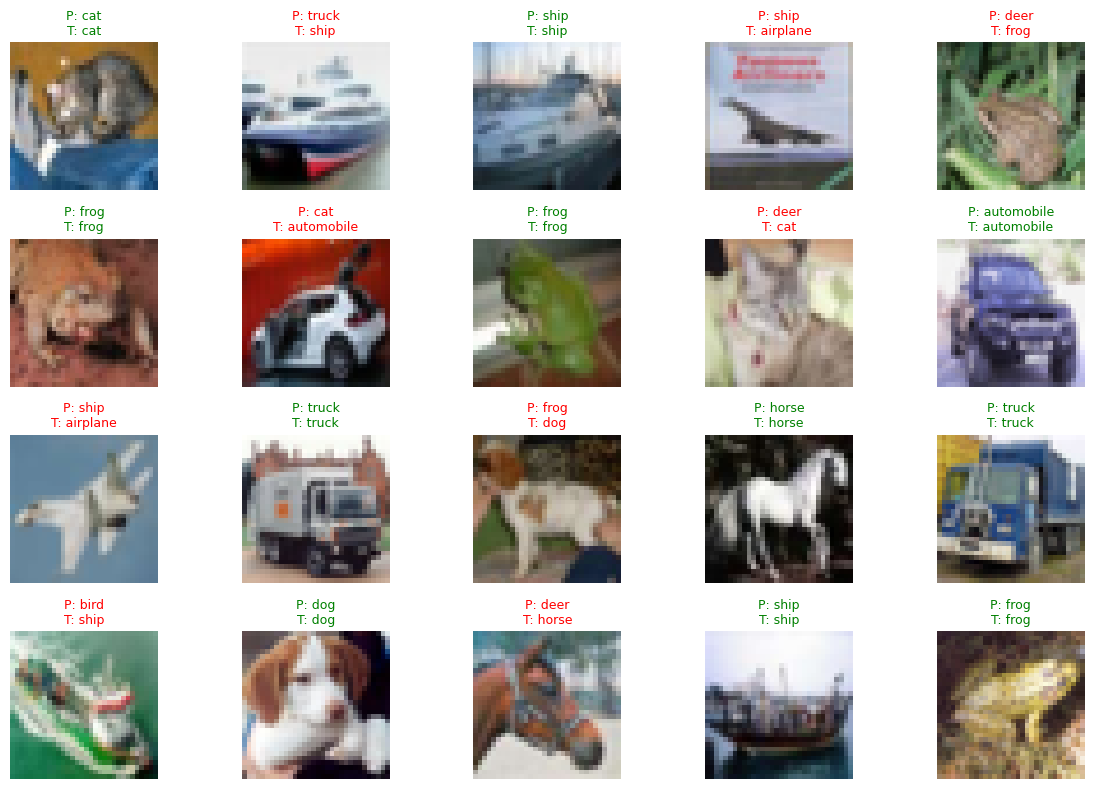

In [12]:
plt.figure(figsize=(12, 8))

for i in range(20):
    prediction = model.predict(X_test[i:i+1], verbose=0)
    predicted_label = np.argmax(prediction)
    true_label = y_test[i]

    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[i])

    color = "green" if predicted_label == true_label else "red"

    plt.title(
        f"P: {class_names[predicted_label]}\nT: {class_names[true_label]}",
        color=color,
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Nhập index ảnh cần dự đoán trong tập test: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Ảnh số: 5
Dự đoán: frog
Thực tế: frog


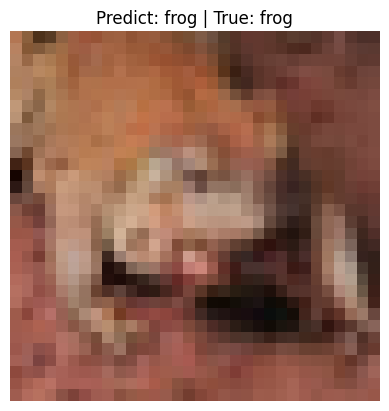

In [13]:
index = int(input("Nhập index ảnh cần dự đoán trong tập test: "))

prediction = model.predict(X_test[index:index+1])
predicted_label = np.argmax(prediction)
true_label = y_test[index]

print("Ảnh số:", index)
print("Dự đoán:", class_names[predicted_label])
print("Thực tế:", class_names[true_label])

plt.imshow(X_test[index])
plt.title(f"Predict: {class_names[predicted_label]} | True: {class_names[true_label]}")
plt.axis("off")
plt.show()

In [14]:
model.save("cifar10_ann_model.h5")

print("Đã lưu model thành công!")

Đã lưu model thành công!


In [15]:
loaded_model = keras.models.load_model("cifar10_ann_model.h5")

loss, acc = loaded_model.evaluate(X_test, y_test, verbose=0)

print("Accuracy sau khi load lại model:", acc)

Accuracy sau khi load lại model: 0.4424999952316284
